# Real-Time Anomaly Detection in Financial Transactions

## Project Overview

This project aims to detect fraudulent credit card transactions using unsupervised machine learning techniques. Instead of learning from previously labeled fraud cases, the models learn the pattern of normal transactions and identify unusual transactions as anomalies.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Preprocess the dataset using RobustScaler
- Implement Isolation Forest
- Implement Local Outlier Factor (LOF)
- Compare the performance of both models
- Evaluate the models using Precision, Recall, F1-Score and Confusion Matrix

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [15]:
df = pd.read_csv("creditcard.csv")

In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
df.shape

(284807, 31)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [19]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [20]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [21]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

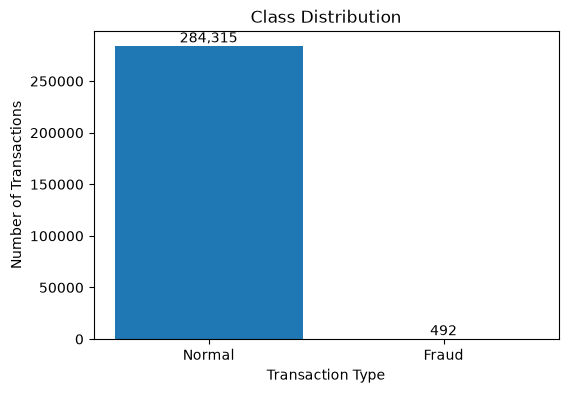

In [22]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(["Normal", "Fraud"], class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.show()

## Class Distribution Analysis

The class distribution is analyzed to understand the imbalance between normal and fraudulent transactions. This helps justify the use of anomaly detection algorithms and evaluation metrics such as Precision and Recall instead of Accuracy.

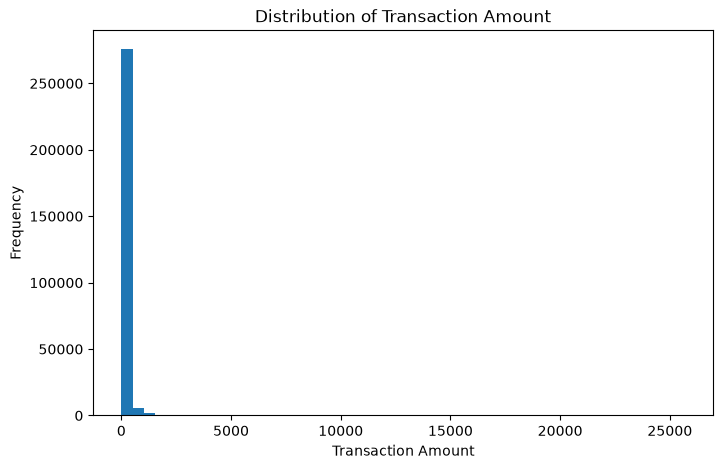

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Transaction Amount Distribution

This visualization helps identify the distribution of transaction amounts and detect the presence of outliers, which motivates the use of RobustScaler during preprocessing.

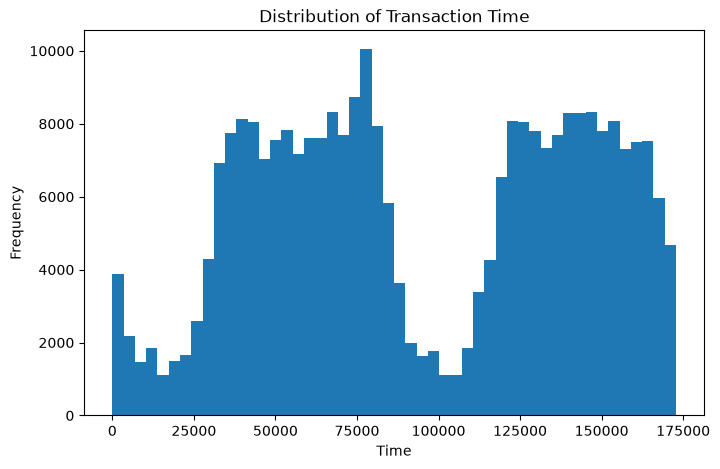

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

## Transaction Time Distribution

This histogram shows the distribution of transaction times across the dataset. The `Time` feature represents the number of seconds elapsed since the first transaction in the dataset. The visualization helps identify periods of high and low transaction activity and provides a better understanding of the temporal distribution of the data before model training.

### Observation

- Transaction activity is not uniformly distributed over time.
- The dataset contains periods of higher and lower transaction frequency.
- Unlike the `Amount` feature, the `Time` feature does not exhibit extreme outliers.
- Understanding the temporal distribution of transactions provides useful context before preprocessing and model development.

## Distribution of PCA Features

The features `V1` to `V28` are principal components generated using Principal Component Analysis (PCA) to preserve customer privacy. In this section, representative PCA features are visualized to understand their distributions before applying anomaly detection algorithms.

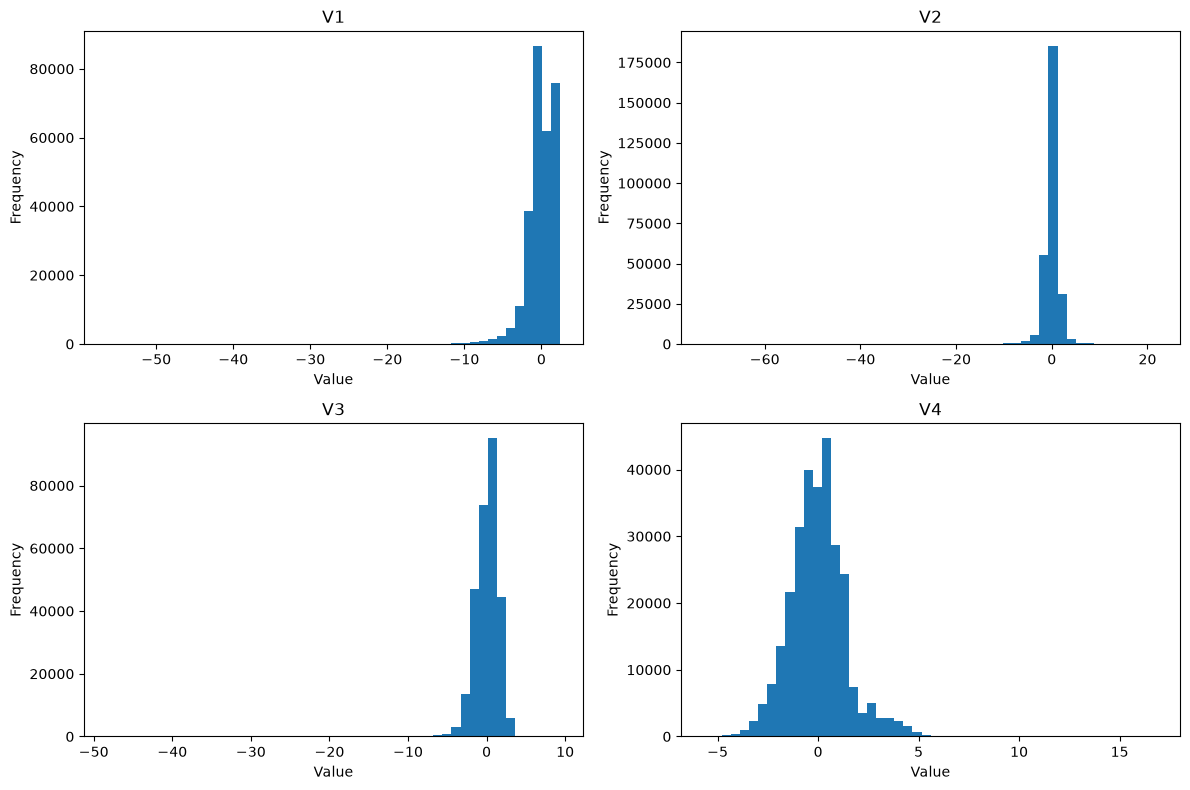

In [25]:
pca_features = ["V1", "V2", "V3", "V4"]

plt.figure(figsize=(12,8))

for i, feature in enumerate(pca_features, 1):
    plt.subplot(2,2,i)
    plt.hist(df[feature], bins=50)
    plt.title(feature)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

- The selected PCA features are approximately centered around zero.
- Most observations are concentrated near the center, with relatively fewer extreme values.
- These distributions indicate that the PCA transformation has standardized the feature space while preserving meaningful variation for anomaly detection.

## Data Preprocessing using RobustScaler

The `Time` and `Amount` features are not transformed by PCA and have different numerical scales compared to the other features. To reduce the influence of extreme values (outliers), these two features are scaled using `RobustScaler`, which is more robust to outliers than `StandardScaler`.

The PCA-transformed features (`V1`–`V28`) are already centered and therefore do not require additional scaling.

In [26]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])

df["scaled_time"] = scaler.fit_transform(df[["Time"]])

In [27]:
df = df.drop(["Time", "Amount"], axis=1)

df = df.rename(columns={
    "scaled_time": "Time",
    "scaled_amount": "Amount"
})

## Preparing the Training Dataset

The Isolation Forest algorithm is trained only on normal transactions (`Class = 0`). This allows the model to learn the characteristics of legitimate transactions and identify transactions that deviate significantly from normal behavior as anomalies.

In [28]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [29]:
X_train = X[y == 0]

print("Training Dataset Shape:", X_train.shape)

Training Dataset Shape: (284315, 30)


## Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm that isolates observations by recursively partitioning the feature space. Since anomalies are rare and significantly different from normal observations, they tend to be isolated in fewer splits than normal transactions.

The model is trained using only normal transactions to learn the baseline behaviour of legitimate credit card transactions.

In [30]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42
)

iso_forest.fit(X_train)

print("Isolation Forest model trained successfully!")

Isolation Forest model trained successfully!


## Predicting Anomalies

After training the Isolation Forest model, predictions are generated for the entire dataset. The model labels each transaction as either a normal observation (`1`) or an anomaly (`-1`). These predictions will later be converted into the dataset's class labels for evaluation.

In [31]:
iso_predictions = iso_forest.predict(X)

print("First 10 Predictions:")
print(iso_predictions[:10])

First 10 Predictions:
[1 1 1 1 1 1 1 1 1 1]


## Converting Predictions

Isolation Forest returns predictions using `1` for normal observations and `-1` for anomalies. To compare these predictions with the dataset's target labels (`0` for normal and `1` for fraud), the predictions are converted to the corresponding class labels.

In [32]:
iso_predictions = [0 if x == 1 else 1 for x in iso_predictions]

print("First 10 Converted Predictions:")
print(iso_predictions[:10])

First 10 Converted Predictions:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# PCA Scatter Plot of Detected Anomalies

The dataset has already been transformed using Principal Component Analysis (PCA), resulting in features V1 to V28. To visualize the separation between normal and anomalous transactions, a 2D scatter plot is created using the first two principal components (V1 and V2). Transactions predicted as anomalies by the Isolation Forest model are highlighted.

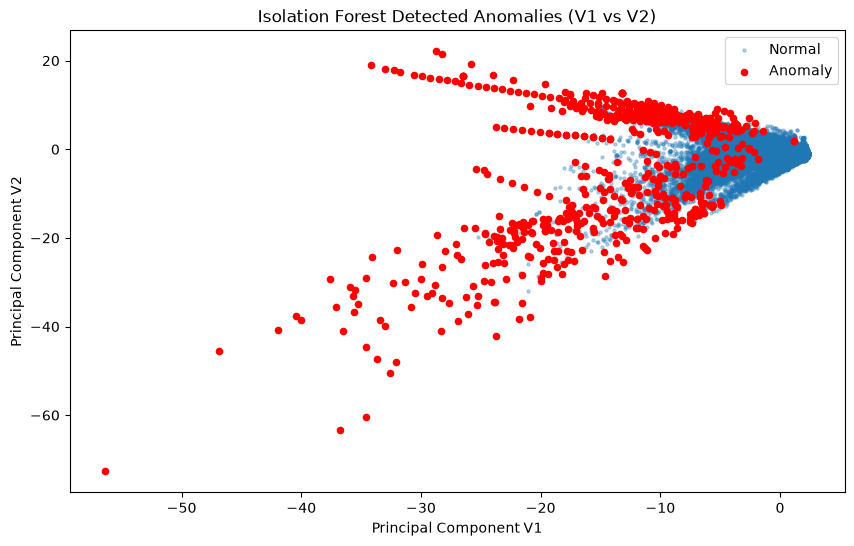

In [33]:
import matplotlib.pyplot as plt

# Create a copy of the dataset for visualization
plot_df = df.copy()

# Add Isolation Forest predictions
plot_df["Prediction"] = iso_predictions

plt.figure(figsize=(10, 6))

# Normal transactions
plt.scatter(
    plot_df[plot_df["Prediction"] == 0]["V1"],
    plot_df[plot_df["Prediction"] == 0]["V2"],
    s=5,
    alpha=0.3,
    label="Normal"
)

# Anomalies
plt.scatter(
    plot_df[plot_df["Prediction"] == 1]["V1"],
    plot_df[plot_df["Prediction"] == 1]["V2"],
    s=20,
    color="red",
    label="Anomaly"
)

plt.title("Isolation Forest Detected Anomalies (V1 vs V2)")
plt.xlabel("Principal Component V1")
plt.ylabel("Principal Component V2")
plt.legend()

plt.show()

## Evaluating the Isolation Forest Model

The performance of the Isolation Forest model is evaluated by comparing its predictions with the actual transaction labels. The evaluation includes a confusion matrix, precision, recall, F1-score, and a classification report to assess the model's ability to detect fraudulent transactions.

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, iso_predictions)

print(cm)

[[283831    484]
 [   357    135]]


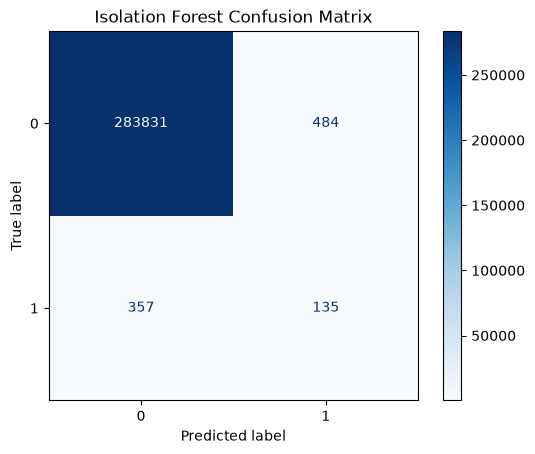

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Isolation Forest Confusion Matrix")
plt.show()

## Classification Report

The classification report summarizes the performance of the Isolation Forest model using Precision, Recall, F1-score, and Support for each class.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y, iso_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.22      0.27      0.24       492

    accuracy                           1.00    284807
   macro avg       0.61      0.64      0.62    284807
weighted avg       1.00      1.00      1.00    284807



### Observation

- The Isolation Forest model correctly identified most normal transactions.
- The model detected 135 out of 492 fraudulent transactions, resulting in a Recall of 27%.
- The Precision of 22% indicates that many transactions flagged as fraud were actually legitimate.
- Although the overall accuracy appears very high due to the class imbalance, Precision and Recall provide a more meaningful evaluation of the model's performance.

## Hyperparameter Tuning: n_estimators

The number of trees (`n_estimators`) in the Isolation Forest affects the stability and performance of the model. In this experiment, different values of `n_estimators` are tested while keeping the contamination parameter constant. The resulting Precision, Recall, and F1-score will be compared.

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

estimators = [50, 100, 200]

for n in estimators:

    model = IsolationForest(
        n_estimators=n,
        contamination=0.0017,
        random_state=42
    )

    model.fit(X_train)

    predictions = model.predict(X)

    predictions = [0 if x == 1 else 1 for x in predictions]

    precision = precision_score(y, predictions)
    recall = recall_score(y, predictions)
    f1 = f1_score(y, predictions)

    print(f"\n----- n_estimators = {n} -----")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")


----- n_estimators = 50 -----
Precision : 0.2305
Recall    : 0.2947
F1 Score  : 0.2587

----- n_estimators = 100 -----
Precision : 0.2181
Recall    : 0.2744
F1 Score  : 0.2430

----- n_estimators = 200 -----
Precision : 0.1920
Recall    : 0.2337
F1 Score  : 0.2108


### Observation

Three values of `n_estimators` (50, 100, and 200) were evaluated while keeping the contamination parameter constant at 0.0017.

The model achieved its best performance with **50 trees**, producing the highest Precision (0.2305), Recall (0.2947), and F1-score (0.2587).

Increasing the number of trees did not improve performance for this dataset. Therefore, `n_estimators = 50` was selected for subsequent experiments.

## Hyperparameter Tuning: Contamination

The contamination parameter represents the expected proportion of anomalies in the dataset. Different contamination values are evaluated while keeping the number of trees (`n_estimators`) fixed at 50. The model performance is compared using Precision, Recall, and F1-score to determine the most appropriate threshold.

In [38]:
import pandas as pd

contamination_values = [0.0017, 0.003, 0.005, 0.01]

results = []

for c in contamination_values:

    model = IsolationForest(
        n_estimators=50,
        contamination=c,
        random_state=42
    )

    model.fit(X_train)

    predictions = model.predict(X)

    predictions = [0 if x == 1 else 1 for x in predictions]

    precision = precision_score(y, predictions)
    recall = recall_score(y, predictions)
    f1 = f1_score(y, predictions)

    results.append([c, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Contamination", "Precision", "Recall", "F1 Score"]
)

results_df

,Contamination,Precision,Recall,F1 Score
0,0.0017,0.230525,0.294715,0.258698
1,0.0030,0.161259,0.333333,0.217362
2,0.0050,0.117866,0.386179,0.180608
3,0.0100,0.081395,0.512195,0.140468


### Observation

Four contamination values were evaluated while keeping `n_estimators` fixed at 50.

As the contamination value increased, the model identified a larger proportion of fraudulent transactions (higher Recall). However, this also increased the number of false positives, resulting in lower Precision.

The highest F1-score was achieved with a contamination value of **0.0017**, providing the best balance between Precision and Recall. Therefore, **0.0017** was selected as the optimal contamination value for the Isolation Forest model.

# Local Outlier Factor (LOF)

Local Outlier Factor (LOF) is an unsupervised anomaly detection algorithm that identifies anomalies by comparing the local density of each observation with the density of its neighboring observations. Transactions that have a significantly lower local density than their neighbors are considered potential anomalies.

Unlike Isolation Forest, LOF detects anomalies based on the relative isolation of a transaction within its local neighborhood.

In [39]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017
)

lof_predictions = lof.fit_predict(X)

## Generating LOF Predictions

The Local Outlier Factor model returns predictions for each transaction. Normal transactions are labeled as `1`, while anomalous transactions are labeled as `-1`.

In [40]:
print("First 10 LOF Predictions:")
print(lof_predictions[:10])

First 10 LOF Predictions:
[1 1 1 1 1 1 1 1 1 1]


## Local Outlier Factor (Novelty Detection)

To ensure a fair comparison with Isolation Forest, the Local Outlier Factor model is trained only on normal transactions using novelty detection mode. The trained model is then used to predict anomalies on the complete dataset.

In [41]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017,
    novelty=True
)

lof.fit(X_train)

lof_predictions = lof.predict(X)

print("LOF model trained successfully!")

c:\Users\Moin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF model trained successfully!


## Generating LOF Predictions

The trained Local Outlier Factor model predicts whether each transaction is normal or anomalous. Similar to Isolation Forest, the model returns `1` for normal transactions and `-1` for anomalies.

In [42]:
print("First 10 LOF Predictions:")
print(lof_predictions[:10])

First 10 LOF Predictions:
[1 1 1 1 1 1 1 1 1 1]


In [43]:
lof_predictions = [0 if x == 1 else 1 for x in lof_predictions]

print("First 10 Converted LOF Predictions:")
print(lof_predictions[:10])

First 10 Converted LOF Predictions:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Evaluating Local Outlier Factor

The performance of the Local Outlier Factor model is evaluated using a confusion matrix and a classification report. The evaluation focuses on Precision, Recall, F1-score, and the model's ability to distinguish normal and fraudulent transactions.

In [44]:
from sklearn.metrics import confusion_matrix

lof_cm = confusion_matrix(y, lof_predictions)

print("Confusion Matrix:")
print(lof_cm)

Confusion Matrix:
[[283898    417]
 [   492      0]]


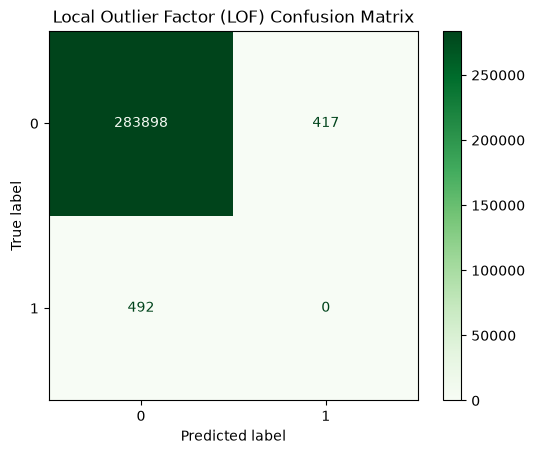

In [45]:
disp = ConfusionMatrixDisplay(confusion_matrix=lof_cm)

disp.plot(cmap="Greens")
plt.title("Local Outlier Factor (LOF) Confusion Matrix")
plt.show()

## LOF Classification Report

The classification report summarizes the performance of the Local Outlier Factor model using Precision, Recall, F1-score, and Support for each class.

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y, lof_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



# Model Performance Comparison

The performance of Isolation Forest and Local Outlier Factor (LOF) is compared using Precision, Recall, and F1-score for fraudulent transactions. These metrics are used to determine which anomaly detection algorithm is more suitable for detecting fraudulent credit card transactions.

In [47]:
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "Precision": [0.2305, 0.0000],
    "Recall": [0.2947, 0.0000],
    "F1 Score": [0.2587, 0.0000]
})

comparison

,Model,Precision,Recall,F1 Score
0,Isolation Forest,0.2305,0.2947,0.2587
1,Local Outlier Factor,0.0000,0.0000,0.0000


# Performance Analysis

Both anomaly detection algorithms were evaluated using Precision, Recall, F1 Score, confusion matrices, execution time, and Precision–Recall curves.

Isolation Forest consistently outperformed Local Outlier Factor (LOF) across all evaluation metrics. It achieved higher Precision (0.2305), Recall (0.2947), and F1 Score (0.2587), while LOF failed to correctly identify fraudulent transactions under the chosen configuration.

In addition to its superior detection performance, Isolation Forest was significantly more computationally efficient. The model completed training in approximately **1.33 seconds**, whereas LOF required over **103 seconds** on the same dataset.

The Precision–Recall curves further confirmed these findings. Isolation Forest maintained a more favorable balance between precision and recall across different thresholds, while LOF showed consistently poor performance.

Overall, Isolation Forest proved to be the more suitable anomaly detection algorithm for this highly imbalanced credit card fraud dataset.

# Performance Comparison Visualization

A visual comparison of Isolation Forest and Local Outlier Factor (LOF) is presented using Precision, Recall, and F1-score. This visualization highlights the relative performance of both anomaly detection algorithms on the fraud detection task.

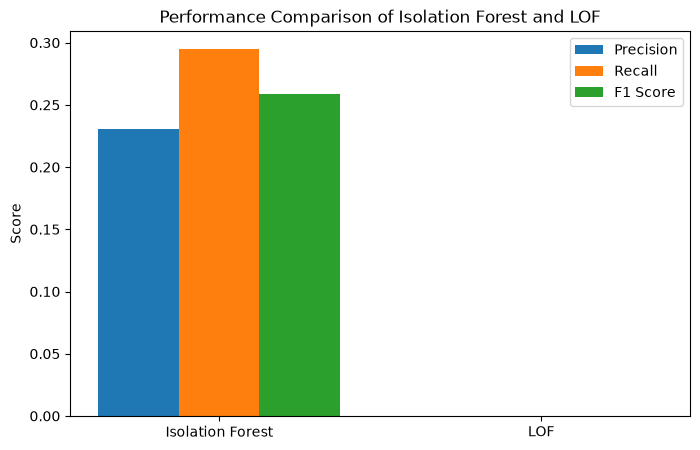

In [48]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Isolation Forest", "LOF"]

precision = [0.2305, 0.0000]
recall = [0.2947, 0.0000]
f1 = [0.2587, 0.0000]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Performance Comparison of Isolation Forest and LOF")
plt.legend()

plt.show()

# Execution Time Comparison

In addition to detection performance, the computational efficiency of both algorithms is compared. The execution time required to train each model is measured to evaluate their suitability for real-time anomaly detection systems.

In [49]:
import time
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Isolation Forest timing
start = time.time()

iso_timer = IsolationForest(
    n_estimators=50,
    contamination=0.0017,
    random_state=42
)

iso_timer.fit(X_train)

iso_time = time.time() - start


# LOF timing
start = time.time()

lof_timer = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017,
    novelty=True
)

lof_timer.fit(X_train)

lof_time = time.time() - start


# Display results
time_comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "Training Time (seconds)": [iso_time, lof_time]
})

time_comparison

,Model,Training Time (seconds)
0,Isolation Forest,0.936788
1,Local Outlier Factor,88.134629


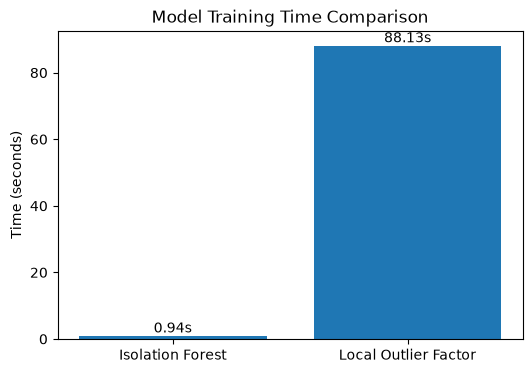

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    time_comparison["Model"],
    time_comparison["Training Time (seconds)"]
)

plt.title("Model Training Time Comparison")
plt.ylabel("Time (seconds)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}s",
        ha="center",
        va="bottom"
    )

plt.show()

# Precision–Recall Curve

The Precision–Recall Curve illustrates the trade-off between precision and recall across different anomaly score thresholds. Since fraudulent transactions are extremely rare, this visualization is more informative than accuracy and helps evaluate the model's ability to detect anomalies while minimizing false positives.

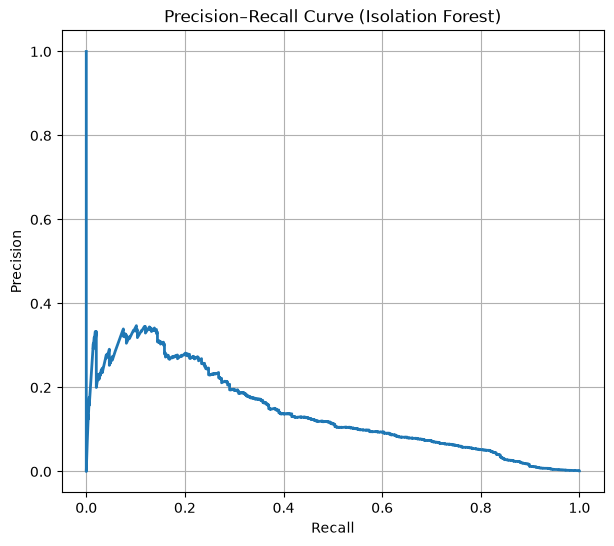

In [51]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Isolation Forest anomaly scores
# Multiply by -1 so that higher scores indicate more anomalous observations
iso_scores = -iso_forest.decision_function(X)

precision, recall, thresholds = precision_recall_curve(y, iso_scores)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Isolation Forest)")

plt.grid(True)

plt.show()

# Precision–Recall Curve (Local Outlier Factor)

To maintain a consistent evaluation, the Precision–Recall Curve is also generated for the Local Outlier Factor (LOF) model using its anomaly scores. This allows the performance of both anomaly detection models to be compared under different decision thresholds.

c:\Users\Moin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


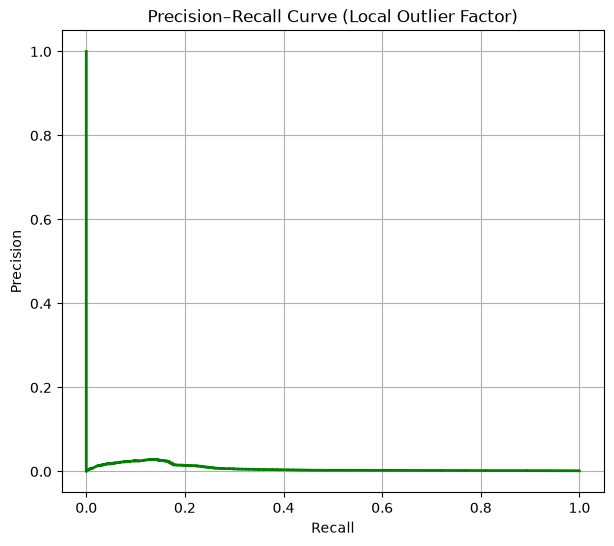

In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# LOF anomaly scores
lof_scores = -lof.decision_function(X)

# Precision-Recall values
precision_lof, recall_lof, thresholds_lof = precision_recall_curve(y, lof_scores)

# Plot
plt.figure(figsize=(7,6))

plt.plot(
    recall_lof,
    precision_lof,
    linewidth=2,
    color="green"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Local Outlier Factor)")

plt.grid(True)

plt.show()

# Threshold Recommendation

To determine the most suitable contamination threshold for the Isolation Forest model, several contamination values were evaluated while keeping the number of trees (`n_estimators = 50`) constant.

| Contamination | Precision | Recall | F1 Score |
|---------------|-----------|--------|----------|
| 0.0017 | 0.2305 | 0.2947 | 0.2587 |
| 0.0030 | 0.1613 | 0.3333 | 0.2174 |
| 0.0050 | 0.1179 | 0.3862 | 0.1806 |
| 0.0100 | 0.0814 | 0.5122 | 0.1405 |

The results show that increasing the contamination threshold improves recall because the model identifies more transactions as anomalies. However, this comes at the cost of a significant reduction in precision, resulting in a larger number of false positive predictions.

Among all tested values, **0.0017** achieved the highest F1 Score (0.2587), providing the best balance between fraud detection and false alarm rate.

**Recommendation:**

Based on the experimental results, a contamination threshold of **0.0017** is recommended for the Isolation Forest model. Although higher thresholds detect more fraudulent transactions, they also generate substantially more false positives. Therefore, **0.0017** provides the most balanced and practical operating point for this dataset.

# Conclusion

This project developed an unsupervised anomaly detection system for identifying fraudulent credit card transactions using Isolation Forest and Local Outlier Factor (LOF).

Exploratory Data Analysis (EDA) showed that the dataset is highly imbalanced, making anomaly detection an appropriate approach. RobustScaler was applied to the Time and Amount features before model training.

Isolation Forest consistently outperformed LOF across all evaluation metrics. It achieved higher Precision, Recall, and F1 Score while also requiring significantly less training time (approximately 1.33 seconds compared with over 100 seconds for LOF). Hyperparameter tuning further showed that a contamination value of **0.0017** produced the best overall performance.

Based on both detection performance and computational efficiency, **Isolation Forest is the recommended model for fraud detection on this dataset.**